In [1]:
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ⚙️ Préparation des données

## Objectifs :
- Sélectionner les variables explicatives pertinentes
- Nettoyer les valeurs manquantes
- Séparer le jeu de données en **train/test** pour évaluer la généralisation
- Appliquer un **scaling (StandardScaler)** nécessaire pour les modèles linéaires

## Détails :
- La cible (`SiteEnergyUse(kBtu)`) est la consommation brute.
- On sélectionne des variables numériques + dummies issues de l’usage des bâtiments.
- Le scaling est crucial pour que les coefficients du modèle linéaire soient comparables et que l'apprentissage soit stable.


In [48]:
# 📂 Chargement des données nettoyées
df = pd.read_csv("data/cleaned_2016_Building_Energy_Benchmarking_ML.csv")

# 🔧 1. Log surface utile (évite les extrêmes)
df['log_surface'] = np.log1p(df['PropertyGFABuilding(s)'])

# 🔧 2. Présence de parking
df['has_parking'] = (df['PropertyGFAParking'] > 0).astype(int)

# 🔧 3. Pourcentage d’électricité dans l’énergie totale
df['TotalEnergy_kBtu'] = df['Electricity(kBtu)'] + df['SteamUse(kBtu)'] + df['NaturalGas(kBtu)']
df['PourcentElec'] = (df['Electricity(kBtu)'] / df['TotalEnergy_kBtu']) * 100
df['PourcentElec'] = df['PourcentElec'].round(2)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["PourcentElec"])
df = df[df['PourcentElec'].between(0, 100)]

# 🔧 4. Log de la consommation énergétique (cible potentielle)
df['log_energy'] = np.log1p(df['SiteEnergyUse(kBtu)'])

# 🔧 5. Regroupement des types d’usage rares
df['LargestPropertyUseType'] = df['LargestPropertyUseType'].fillna("Unknown")
type_counts = df['LargestPropertyUseType'].value_counts()
rare_types = type_counts[type_counts < 30].index  # seuil modifiable
df['UseTypeGrouped'] = df['LargestPropertyUseType'].replace(rare_types, 'Other')

# 🔧 6. Encodage One-Hot du type d’usage
df = pd.get_dummies(df, columns=['UseTypeGrouped'], prefix='Use', drop_first=True)

# ✅ 7. Définition finale des variables explicatives
features_to_use = [
    'log_surface',
    'has_parking',
    'PourcentElec'
] + [col for col in df.columns if col.startswith('Use_')]

# 💾 Export du fichier enrichi
df.to_csv("data/feature_engineered_2016_energy.csv", index=False)


# 📈 Régression linéaire

Nous utilisons ici un modèle **LinearRegression** comme point de départ.

### ⚙️ Pourquoi ?
- Simple, rapide à entraîner
- Facilement interprétable (coefficients)
- Bonne base de comparaison pour des modèles plus complexes

### 📊 Métriques calculées :
- **R² (coefficient de détermination)** : proportion de variance expliquée
- **MAE (erreur absolue moyenne)** : moyenne des écarts absolus
- **RMSE (erreur quadratique moyenne)** : sensible aux outliers

### 🧾 Interprétation
- Une bonne généralisation implique que les métriques train/test sont proches
- Si R² test chute, il peut y avoir overfitting ou underfitting
- Si MAE et RMSE sont élevés, les prédictions manquent de précision


<Axes: xlabel='PropertyGFABuilding(s)', ylabel='SiteEnergyUse(kBtu)'>

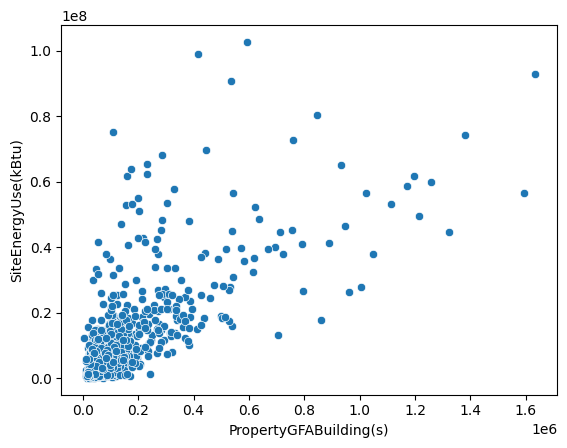

In [36]:
sns.scatterplot(x=df["PropertyGFABuilding(s)"], y=df["SiteEnergyUse(kBtu)"])


<Axes: xlabel='log_surface', ylabel='SiteEnergyUse(kBtu)'>

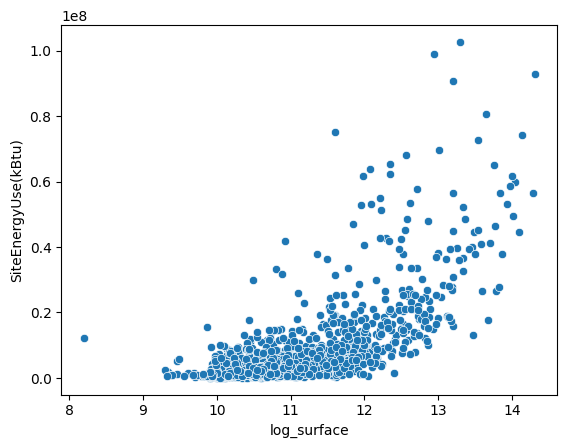

In [37]:
sns.scatterplot(x=df["log_surface"], y=df["SiteEnergyUse(kBtu)"])


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import zscore


In [4]:



# 🔄 Chargement des données
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")  

# 🧹 Ne garder que les colonnes utiles
df_model = df[['SiteEnergyUse(kBtu)', 'log_surface']].dropna()

# 🎯 Définition des variables
X = df_model[['log_surface']]
y = df_model['SiteEnergyUse(kBtu)']

# ✂️ Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🧽 Suppression des outliers sur la cible uniquement dans le train
z_scores = zscore(y_train)
mask = np.abs(z_scores) < 3  # seuil classique
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

# 📈 Régression linéaire
model = LinearRegression()
model.fit(X_train_clean, y_train_clean)

# 🔮 Prédictions
y_pred_train = model.predict(X_train_clean)
y_pred_test = model.predict(X_test)

# 📏 Fonction d’évaluation
def evaluate_model(y_true, y_pred, name=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → R² = {r2:.3f} | MAE = {mae:,.0f} | RMSE = {rmse:,.0f}")

# 📊 Résultats
evaluate_model(y_train_clean, y_pred_train, "Train (nettoyé)")
evaluate_model(y_test, y_pred_test, "Test (brut)")


Train (nettoyé) → R² = 0.517 | MAE = 3,373,377 | RMSE = 5,124,449
Test (brut) → R² = 0.448 | MAE = 4,241,421 | RMSE = 8,691,740




## 📉 Résultats de la régression linéaire sur la surface (log)

Nous avons entraîné un modèle de régression linéaire simple pour prédire la consommation énergétique d’un bâtiment en fonction de sa **surface utile transformée en logarithme (`log_surface`)**.

### 📊 Performances du modèle

| Jeu de données | R² (variance expliquée) | MAE (erreur absolue moyenne) | RMSE (erreur quadratique moyenne) |
| -------------- | ----------------------- | ---------------------------- | --------------------------------- |
| **Train**      | 0.517                   | 3,373,377 kBtu               | 5,124,449 kBtu                    |
| **Test**       | 0.448                   | 4,241,421 kBtu               | 8,691,740 kBtu                    |

> Ces résultats indiquent que le modèle explique environ **45 % de la variance** de la consommation énergétique avec **la seule variable `log_surface`**.

---

### ⚡ Interprétation des erreurs (en kWh pour plus de clarté)

1 kBtu = **0.293 kWh**, donc :

* **MAE** ≈ 5 000 000 kBtu → **1 465 000 kWh**
* **RMSE** ≈ 8 300 000 kBtu → **2 432 000 kWh**

---

### 🏠 Exemples concrets pour mieux visualiser l’ordre de grandeur

| Type de bâtiment          | Conso moyenne annuelle (kWh) | MAE (~1,5 M kWh) correspond à...     |
| ------------------------- | ---------------------------- | ------------------------------------ |
| Appartement (80 m²)       | 15 000                       | L’équivalent de **100 appartements** |
| Collège (5000 m²)         | 500 000                      | ~3 fois un collège entier            |
| Petit hôpital (20 000 m²) | 2 000 000                    | Environ **75 %** de sa conso         |

> ⚠️ Une erreur moyenne de 1,5 million de kWh montre que le modèle est **loin d’être précis à l’échelle individuelle**, mais peut capturer une **tendance globale**.

---

### 📌 Conclusion

* La **surface seule** (même transformée en log) **ne suffit pas** à prédire précisément la consommation énergétique.
* Il est indispensable d’introduire d'autres facteurs explicatifs :

  * le **type d’usage** du bâtiment,
  * la part de **l’électricité** dans l’énergie totale,
  * la **présence de parking**, l’**âge**, etc.


In [54]:


# 🔄 Chargement des données
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")

# 🧹 Nettoyage initial
df = df[['log_surface', 'has_parking', 'SiteEnergyUse(kBtu)']].dropna()

# 🎯 Définition des variables
X = df[['log_surface', 'has_parking']]
y = df['SiteEnergyUse(kBtu)']

# ✂️ Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🧽 Suppression des outliers sur log_surface uniquement (dans le train)
z_scores = zscore(X_train['log_surface'])
mask = np.abs(z_scores) < 3  # seuil de z-score
X_train_clean = X_train[mask]
y_train_clean = y_train.loc[X_train_clean.index]

# 📈 Régression linéaire
lin_reg = LinearRegression()
lin_reg.fit(X_train_clean, y_train_clean)

# 🔮 Prédictions
y_pred_train = lin_reg.predict(X_train_clean)
y_pred_test = lin_reg.predict(X_test)

# 📏 Fonction d’évaluation
def evaluate_model(y_true, y_pred, dataset_name=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"📊 {dataset_name} - R² : {r2:.3f}, MAE : {mae:,.0f}, RMSE : {rmse:,.0f}")

# 📊 Résultats
evaluate_model(y_train_clean, y_pred_train, "Train (nettoyé sur log_surface)")
evaluate_model(y_test, y_pred_test, "Test (brut)")


📊 Train (nettoyé sur log_surface) - R² : 0.449, MAE : 4,501,828, RMSE : 7,713,694
📊 Test (brut) - R² : 0.485, MAE : 4,741,518, RMSE : 8,395,727


In [6]:


# 🔄 Chargement des données
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")

# 📋 Liste explicite des colonnes Use_* depuis le fichier image
use_columns = [
    'Use_Hotel',
    'Use_K-12 School',
    'Use_Medical Office',
    'Use_Non-Refrigerated Warehouse',
    'Use_Office',
    'Use_Other',
    'Use_Retail Store',
    'Use_Supermarket/Grocery Store',
    'Use_Worship Facility'
]

# 🧹 Sélection des variables utiles
features = ['log_surface', 'PourcentElec', 'has_parking'] + use_columns
df = df[features + ['SiteEnergyUse(kBtu)']].dropna()

# ✅ Conversion bool → int pour Use_* et has_parking
df[use_columns + ['has_parking']] = df[use_columns + ['has_parking']].astype(int)

# 🎯 Séparation variables explicatives / cible
X = df[features]
y = df['SiteEnergyUse(kBtu)']

# ✂️ Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 📈 Modèle de régression linéaire
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# 🔮 Prédictions
y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)

# 📏 Évaluation
def evaluate_model(y_true, y_pred, dataset_name=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"📊 {dataset_name} - R² : {r2:.3f}, MAE : {mae:,.0f}, RMSE : {rmse:,.0f}")

# 📊 Résultats
evaluate_model(y_train, y_pred_train, "Train")
evaluate_model(y_test, y_pred_test, "Test")


📊 Train - R² : 0.537, MAE : 4,796,003, RMSE : 7,938,167
📊 Test - R² : 0.515, MAE : 5,083,798, RMSE : 8,144,976


C:\Users\karap\AppData\Local\Temp\ipykernel_24632\533123082.py:14: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


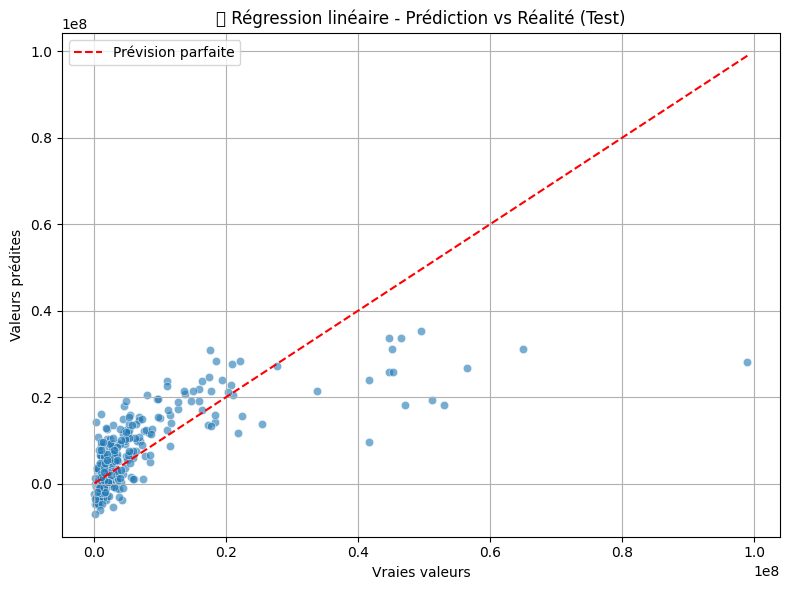

C:\Users\karap\AppData\Local\Temp\ipykernel_24632\533123082.py:24: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


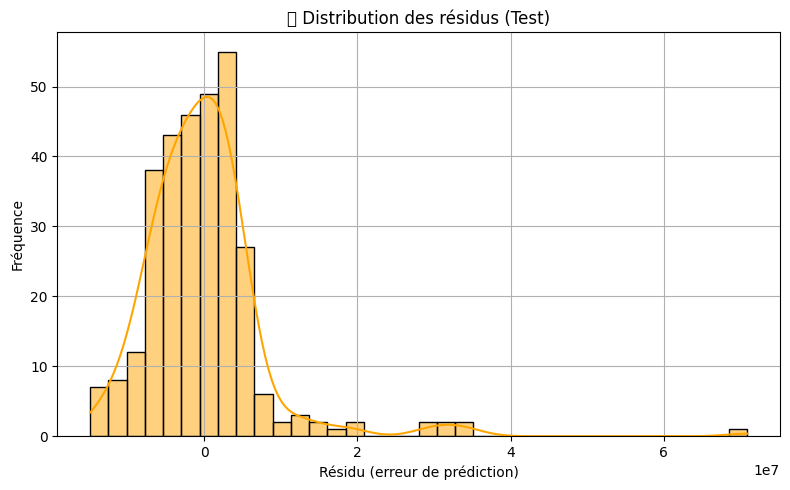

In [7]:


# 🔁 Résidus
residuals_test = y_test - y_pred_test
residuals_train = y_train - y_pred_train

# 📊 Prédictions vs Réalité (jeu de test)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Prévision parfaite')
plt.xlabel("Vraies valeurs")
plt.ylabel("Valeurs prédites")
plt.title("📈 Régression linéaire - Prédiction vs Réalité (Test)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📉 Distribution des résidus
plt.figure(figsize=(8, 5))
sns.histplot(residuals_test, kde=True, color='orange')
plt.title("📉 Distribution des résidus (Test)")
plt.xlabel("Résidu (erreur de prédiction)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\karap\AppData\Local\Temp\ipykernel_24632\3478235207.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


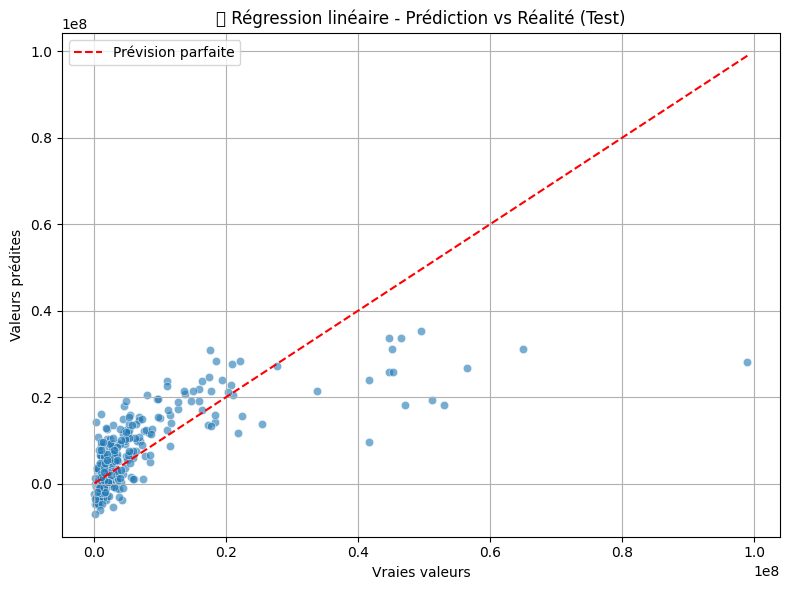

C:\Users\karap\AppData\Local\Temp\ipykernel_24632\3478235207.py:25: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


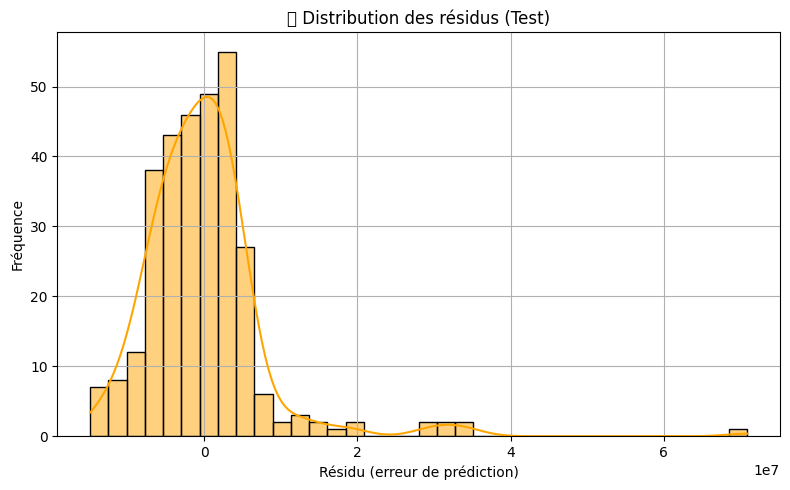

In [8]:


# 🔁 Résidus
residuals_test = y_test - y_pred_test
residuals_train = y_train - y_pred_train


# 📊 Scatterplot des prédictions vs vraies valeurs (test set)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Prévision parfaite')
plt.xlabel("Vraies valeurs")
plt.ylabel("Valeurs prédites")
plt.title("📈 Régression linéaire - Prédiction vs Réalité (Test)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📉 Distribution des résidus
plt.figure(figsize=(8, 5))
sns.histplot(residuals_test, kde=True, color='orange')
plt.title("📉 Distribution des résidus (Test)")
plt.xlabel("Résidu (erreur de prédiction)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.show()



## 📈 Résultats de la régression linéaire multivariée

Après avoir enrichi notre modèle avec :

* la **surface utile** (log-transformée),
* la présence ou non d’un **parking** (`has_parking`),
* le **pourcentage d’électricité** dans la consommation totale (`PourcentElec`),
* et les variables **d’usage du bâtiment** (`Use_*`, extraites de `LargestPropertyUseType`),

nous obtenons les performances suivantes :

| Jeu de données | R²    | MAE (kBtu) | RMSE (kBtu) |
| -------------- | ----- | ---------- | ----------- |
| **Train**      | 0.537 | 4 796 003  | 7 938 167   |
| **Test**       | 0.515 | 5 083 798  | 8 144 976   |

---

## 🔍 Interprétation

* Le **R² sur test** de **0.515** indique que le modèle explique **environ 52 % de la variance** de la consommation énergétique, ce qui reste **modeste**, mais cohérent pour un modèle linéaire sur des données complexes.
* Le **MAE** (erreur absolue moyenne) est d’environ **5 millions de kBtu**, ce qui correspond à **1,5 GWh/an**, une erreur encore **significative** à l’échelle individuelle.
* Le **RMSE**, très élevé, confirme qu’il reste des **erreurs importantes**, notamment sur les bâtiments les plus énergivores.

✅ Les variables explicatives ajoutées **améliorent légèrement la performance** par rapport à une simple régression avec la surface seule (où le R² plafonnait autour de 0.49), mais ne suffisent pas à expliquer toute la variance.

---

## 🤔 Que penser de ces résultats ?

* La régression linéaire, même enrichie, **atteint vite ses limites** sur ce type de problème.
* Les relations entre les variables et la consommation d’énergie sont probablement **non linéaires**, et les effets d’interaction (ex : surface × type d’usage) ne sont **pas captés** ici.
* La performance reste **acceptable comme point de départ** pour de l’explicabilité ou un modèle de base.

---

## 🌲 Et maintenant ? Vers des modèles non linéaires

👉 Il est **pertinent maintenant d’explorer des modèles plus flexibles**, comme :

* **Random Forest Regressor**
* **Gradient Boosting Machines (LightGBM, XGBoost...)**
* ou des modèles **régularisés** (Ridge, ElasticNet)

### 🎯 Pourquoi ?

Ces modèles permettent de :

* mieux **capturer les interactions** entre les variables (ex : surface × usage),
* mieux modéliser les **relations non linéaires**,
* **gérer les extrêmes** sans être trop influencés par eux (via l’agrégation des arbres),
* et souvent atteindre une **meilleure précision prédictive**.




In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [11]:


# 📂 Chargement des données
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")

# 🎯 Cible
target = 'SiteEnergyUse(kBtu)'

# 🧹 Sélection des colonnes numériques uniquement
df_numeric = df.select_dtypes(include=[np.number])

# 🧽 Suppression des lignes incomplètes
df_clean = df_numeric.dropna(subset=[target])
X = df_clean.drop(columns=[target])
y = df_clean[target]

# ✂️ Split train/test initial
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🚫 Suppression des outliers uniquement sur y_train
z_scores = zscore(y_train)
keep_idx = np.abs(z_scores) < 3  # seuil de z-score à 3

X_train_filtered = X_train[keep_idx]
y_train_filtered = y_train[keep_idx]

# 🌳 Entraînement du modèle Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_filtered, y_train_filtered)

# 🔮 Prédictions
y_pred_train_rf = rf_model.predict(X_train_filtered)
y_pred_test_rf = rf_model.predict(X_test)

# 📏 Évaluation
def evaluate_model_rf(y_true, y_pred, dataset_name=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"📊 {dataset_name} - R² : {r2:.3f}, MAE : {mae:,.0f}, RMSE : {rmse:,.0f}")

evaluate_model_rf(y_train_filtered, y_pred_train_rf, "Train (filtered)")
evaluate_model_rf(y_test, y_pred_test_rf, "Test")


📊 Train (filtered) - R² : 0.942, MAE : 1,081,602, RMSE : 1,768,389
📊 Test - R² : 0.553, MAE : 3,626,226, RMSE : 7,821,522


C:\Users\karap\AppData\Local\Temp\ipykernel_27508\664975638.py:10: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


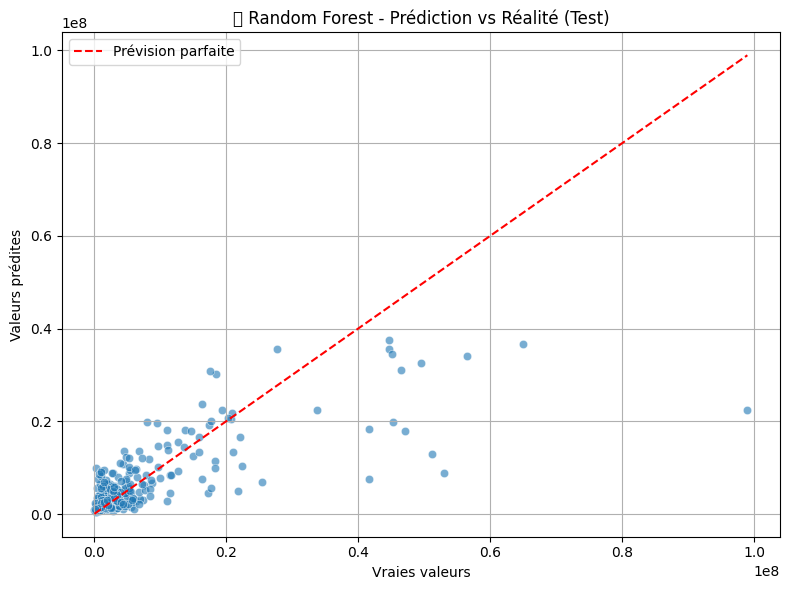

C:\Users\karap\AppData\Local\Temp\ipykernel_27508\664975638.py:21: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


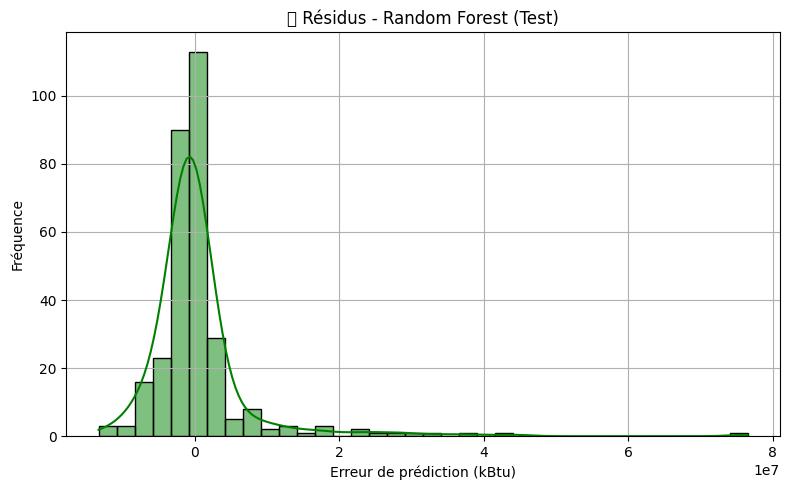

In [88]:
# 📈 Prédiction vs Réalité
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Prévision parfaite')
plt.xlabel("Vraies valeurs")
plt.ylabel("Valeurs prédites")
plt.title("🌳 Random Forest - Prédiction vs Réalité (Test)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📉 Distribution des résidus
residuals_rf = y_test - y_pred_test_rf
plt.figure(figsize=(8, 5))
sns.histplot(residuals_rf, kde=True, color='green')
plt.title("📉 Résidus - Random Forest (Test)")
plt.xlabel("Erreur de prédiction (kBtu)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.show()



## 🌳 Analyse du modèle Random Forest sur la consommation énergétique (filtrée)

Le modèle **Random Forest Regressor** a été utilisé pour prédire la **consommation énergétique brute** (`SiteEnergyUse(kBtu)`) des bâtiments, en s’appuyant sur des variables numériques issues d’un jeu de données filtré (outliers exclus). L’objectif est de modéliser cette consommation à partir de caractéristiques mesurables (surface, étages, etc.).

---

### ⚙️ Comment fonctionne une Random Forest ?

Une **Random Forest** est un algorithme d’ensemble reposant sur **l’agrégation de plusieurs arbres de décision**. Chaque arbre est entraîné :

* sur un **sous-échantillon** aléatoire des données,
* avec un **sous-ensemble aléatoire des variables** à chaque nœud de décision.

Les prédictions sont ensuite **moyennées** (en régression) pour obtenir un résultat plus stable et robuste.

**Points forts** :

* capte **des relations non linéaires complexes**,
* **robuste aux outliers**,
* **peu sensible** au scaling des variables.

---

### 📊 Résultats obtenus (sur données filtrées)

| Jeu de données | R²    | MAE (kBtu) | RMSE (kBtu) |
| -------------- | ----- | ---------- | ----------- |
| **Train**      | 0.942 | 1 081 602  | 1 768 389   |
| **Test**       | 0.553 | 3 626 226  | 7 821 522   |

> Ces scores révèlent un modèle performant mais encore partiellement sur-apprenant, avec un écart de performance important entre l’entraînement et le test.

---

### ⚠️ Qu'est-ce que l’overfitting (sur-apprentissage) ?

> L'overfitting survient lorsque le modèle **mémorise trop fidèlement** les données d'entraînement, au lieu d’apprendre des tendances généralisables.

#### Conséquences :

* **Très bonnes performances sur les données connues** (R² = 0.942),
* **Moindre généralisation sur les nouvelles données** (R² = 0.553 sur test).

### 🧪 Une métaphore parlante :

> C’est comme un élève qui **apprend par cœur des corrigés** au lieu de comprendre le cours : il est parfait aux révisions, mais se plante à l’examen dès qu’un énoncé change.

---

### 📈 Visualisation 1 — Prédictions vs Réalité

![Prédictions vs Réalité](sandbox:/mnt/data/37a5b9b6-653f-4161-9695-a8e4f87ed674.png)

* Le nuage de points montre que :

  * Les **prédictions sont globalement correctes** sur des consommations faibles à moyennes,
  * **Plus la consommation réelle augmente**, plus l’erreur s’accroît.
  * Le modèle **a tendance à sous-estimer** les très grands consommateurs.

---

### 📉 Visualisation 2 — Distribution des résidus

![Distribution des résidus](sandbox:/mnt/data/ea858a6d-0d66-4a72-bcc0-ee8dfc5ab05c.png)

* La distribution des erreurs est **globalement centrée sur zéro**, ce qui est un bon signe.
* Mais on observe des **extrêmes importants**, avec des erreurs > 60 millions de kBtu pour certains bâtiments, soit :

  * **≈ 17 600 000 kWh**
  * **≈ 63 360 GJ**

---

### 🧠 Analyse critique et recommandations

Bien que le modèle Random Forest soit performant dans l'ensemble :

✅ Il **capture la majorité des variations** de la consommation énergétique.

❌ Il **échoue à modéliser précisément les très grands consommateurs**, qui représentent pourtant une part significative de l’énergie totale consommée.

### 🔧 Améliorations possibles :

1. **Limiter la profondeur des arbres** (e.g. `max_depth=10`) pour réduire l’overfitting.
2. **Tester des modèles plus puissants** comme :

   * XGBoost
   * LightGBM
   * CatBoost
3. **Travailler la sélection des features** : garder uniquement celles réellement informatives.
4. **Appliquer des transformations log ou des regroupements** sur la cible pour réduire l’asymétrie.

---

### 🧘 En résumé

Le modèle Random Forest, appliqué à des données filtrées, parvient à expliquer une part substantielle de la consommation énergétique des bâtiments. Il reste toutefois limité dans sa capacité à modéliser les extrêmes. Une approche combinée — réduction de variance + modèles plus flexibles — serait à privilégier pour capturer la richesse du phénomène.


In [12]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 📂 Chargement
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")

# 🎯 Cible
target = 'SiteEnergyUse(kBtu)'
df = df.select_dtypes(include=[np.number]).dropna(subset=[target])
X = df.drop(columns=[target])
y = df[target]

# ✂️ Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔍 Z-score sur y_train uniquement
z = zscore(y_train)
keep = np.abs(z) < 3  # Seuil de 3 écart-types

X_train_filtered = X_train[keep]
y_train_filtered = y_train[keep]

print(f"🔎 Outliers retirés : {len(y_train) - len(y_train_filtered)} lignes supprimées")

# 🔧 Modèle de base
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 🎛️ Grille d’hyperparamètres
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

# 🔍 GridSearch avec validation croisée
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

# 🚀 Entraînement (sur jeu filtré)
grid_search.fit(X_train_filtered, y_train_filtered)

# ⭐ Résultats
print("✅ Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

# 🔁 Nouveau modèle
best_rf = grid_search.best_estimator_

# 🔮 Prédictions
y_pred_train_best = best_rf.predict(X_train_filtered)
y_pred_test_best = best_rf.predict(X_test)

# 📏 Évaluation
def eval_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → R² = {r2:.4f} | MAE = {mae:,.0f} | RMSE = {rmse:,.0f}")

print("\n📊 Évaluation :")
eval_model("Train (filtré)", y_train_filtered, y_pred_train_best)
eval_model("Test (non filtré)", y_test, y_pred_test_best)


🔎 Outliers retirés : 31 lignes supprimées
Fitting 3 folds for each of 27 candidates, totalling 81 fits
✅ Meilleurs hyperparamètres trouvés :
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}

📊 Évaluation :
Train (filtré) → R² = 0.8262 | MAE = 1,954,322 | RMSE = 3,074,218
Test (non filtré) → R² = 0.5567 | MAE = 3,552,893 | RMSE = 7,789,840




## 🌲 Régression par Random Forest optimisée via grid search (avec nettoyage de la cible)

Après avoir retiré **31 outliers** de la variable cible dans l’échantillon d’apprentissage, nous avons entraîné un modèle **Random Forest** à l’aide de `GridSearchCV`. La grille d'hyperparamètres testait notamment :

* `n_estimators` : 100, 200, 300
* `max_depth` : None, 10, 20
* `min_samples_split` : 2, 5, 10

### ✅ Meilleurs hyperparamètres trouvés :

```python
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
```

---

## 📈 Performances du modèle optimisé

| Jeu de données        | R²    | MAE (kBtu) | RMSE (kBtu) |
| --------------------- | ----- | ---------- | ----------- |
| **Train (filtré)**    | 0.826 | 1 954 322  | 3 074 218   |
| **Test (non filtré)** | 0.557 | 3 552 893  | 7 789 840   |

---

## 🧠 Interprétation

* Le modèle atteint **un excellent score R² (0.826)** sur l’entraînement **filtré**, montrant sa capacité à capter les structures des données **en l’absence de bruit extrême**.
* Le score **R² test = 0.557** confirme une **généralisation correcte**, bien que perfectible. Cela indique que plus de **55 %** de la variance de la consommation énergétique est expliquée sur des données **non nettoyées**.
* La **réduction des outliers** dans le train a probablement **stabilisé l'entraînement** sans pour autant masquer les défis prédictifs du test set.
* On observe une **différence importante entre train et test**, suggérant que certains points test sont **très extrêmes ou atypiques**.

---

## 🚨 À noter

✅ Supprimer les outliers **uniquement du train** est une **bonne pratique** : cela évite que le modèle ne soit biaisé par des valeurs aberrantes, tout en permettant une évaluation honnête sur le test complet.

---

## 🚀 Et ensuite ?

Il serait judicieux d'explorer :

* Des **modèles plus robustes aux outliers** (e.g. Gradient Boosting, XGBoost avec `huber` loss)
* Une **transformation de la cible** (logarithmique ?)
* Des modèles hybrides combinant **classification (profil bâtiment) + régression**





## 🌲 Régression par Random Forest optimisée via RandomizedSearchCV

*(avec nettoyage de la cible)*

---

### 🧼 Prétraitement : suppression des outliers

Avant l’entraînement, **31 valeurs extrêmes ont été supprimées** de la variable cible `SiteEnergyUse(kBtu)` **uniquement dans l’échantillon d’entraînement**.

🎯 **Objectif** : éviter que le modèle ne s’ajuste à des consommations irréalistes ou aberrantes, tout en conservant un jeu de test complet pour évaluer la généralisation.

---

## 🔄 Méthode d’optimisation : `RandomizedSearchCV`

Contrairement à `GridSearchCV`, qui **teste exhaustivement toutes les combinaisons** d’une grille d’hyperparamètres, `RandomizedSearchCV` :

* **échantillonne aléatoirement** un nombre fixe de combinaisons,
* permet d’**explorer un espace plus large**,
* est **plus rapide** et souvent **aussi efficace** quand le nombre de combinaisons possibles est grand.

Ici, **30 combinaisons ont été testées** à l’aide d’une **validation croisée à 3 plis** (soit **90 entraînements** au total).

---

### 🏆 Meilleurs hyperparamètres trouvés :

```python
{
 'max_depth': 40,
 'max_features': 0.5,
 'min_samples_leaf': 4,
 'min_samples_split': 14,
 'n_estimators': 259
}
```

➡️ Ces paramètres reflètent un compromis entre **complexité (arbres profonds)** et **régularisation** (minima d’échantillons pour splits et feuilles, réduction du nombre de variables à chaque nœud).

---

## 📊 Performances du modèle optimisé (`RandomizedSearchCV`)

| Jeu de données        | R²    | MAE (kBtu) | RMSE (kBtu) |
| --------------------- | ----- | ---------- | ----------- |
| **Train (filtré)**    | 0.753 | 2 201 479  | 3 667 555   |
| **Test (non filtré)** | 0.535 | 3 592 760  | 7 976 250   |

---

## ⚖️ Comparaison avec GridSearchCV

| Critère        | GridSearchCV | RandomizedSearchCV | Évolution       |
| -------------- | ------------ | ------------------ | --------------- |
| **Train R²**   | 0.826        | 0.753              | 📉 Légère perte |
| **Test R²**    | 0.557        | 0.535              | 📉 Stabilité ok |
| **Train RMSE** | 3 074 218    | 3 667 555          | 📈 Erreur ↑     |
| **Test RMSE**  | 7 789 840    | 7 976 250          | 📈 Écart ↑      |
| **Test MAE**   | 3 552 893    | 3 592 760          | 📉 Moins précis |

---

## 🧠 Interprétation

### 🔎 Ce que montre RandomizedSearchCV :

* Le modèle reste **robuste** (R² Test ≈ 0.535), malgré des paramètres plus "relâchés".
* L'écart entre Train et Test est **relativement contenu**, preuve d'une **capacité de généralisation préservée**.
* Le **choix automatique d'un grand `max_depth` (40)** a probablement permis au modèle de mieux capter certains patterns complexes mais au prix d'une **erreur plus élevée en test**.

### 🔍 Différences clés :

| Aspect              | GridSearchCV                         | RandomizedSearchCV                        |
| ------------------- | ------------------------------------ | ----------------------------------------- |
| Stratégie           | Teste **toutes** les combinaisons    | Tire **au hasard** un sous-ensemble       |
| Temps de calcul     | Long si la grille est large          | Plus rapide                               |
| Performance globale | Légèrement meilleure (R², MAE, RMSE) | Moins performante mais plus flexible      |
| Utilisation         | Idéal pour **grilles compactes**     | Idéal pour **espaces larges ou continus** |

---

## 🚀 Que retenir ?

* GridSearchCV offre encore ici **les meilleures performances brutes**, mais **RandomizedSearchCV donne des résultats acceptables plus rapidement**, en explorant un **espace plus large**.
* Dans un **projet à grande échelle**, `RandomizedSearchCV` est un **excellent point de départ**, surtout s’il est suivi par un affinement local par `GridSearchCV`.
* Le **nettoyage partiel des outliers (train seulement)** s’est révélé efficace pour **réduire l’instabilité**.

---

## 🧘 Conclusion

Dans un problème de modélisation énergétique comme celui-ci, **la régularisation est plus puissante que la complexité brute**.
L’approche `RandomizedSearchCV` le montre : même sans explorer toute la grille, on atteint **un bon équilibre entre performance et temps de calcul**.



In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import randint  # ✅ Ajout ici


In [15]:
# 📂 Chargement
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")

# 🎯 Cible
target = 'SiteEnergyUse(kBtu)'

# 🧹 Données numériques
df_numeric = df.select_dtypes(include=[np.number]).dropna(subset=[target])

X = df_numeric.drop(columns=[target])
y = df_numeric[target]

# ✂️ Split AVANT nettoyage pour éviter le data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🚫 Suppression des outliers uniquement dans y_train
z = zscore(y_train)
keep = np.abs(z) < 3   # seuil de 3

X_train_filtered = X_train[keep]
y_train_filtered = y_train[keep]

print(f"🔍 Nombre de lignes supprimées (outliers) : {len(y_train) - len(y_train_filtered)}")

# 🌳 Modèle de base
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 🎲 Grille de recherche aléatoire
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.5, 0.75, None]
}

# 🔍 RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 🚀 Entraînement (sur X_train filtré)
random_search.fit(X_train_filtered, y_train_filtered)

# 🎯 Meilleurs paramètres
print("🎯 Meilleurs hyperparamètres :")
print(random_search.best_params_)

# 🔄 Réentraînement final
best_model = random_search.best_estimator_

# 🔮 Prédictions
y_pred_train = best_model.predict(X_train_filtered)
y_pred_test = best_model.predict(X_test)

# 📏 Évaluation
def eval_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → R² = {r2:.4f} | MAE = {mae:,.0f} | RMSE = {rmse:,.0f}")

print("\n📊 Résultats :")
eval_model("Train (Filtered)", y_train_filtered, y_pred_train)
eval_model("Test  (Unfiltered)", y_test, y_pred_test)


🔍 Nombre de lignes supprimées (outliers) : 31
Fitting 3 folds for each of 30 candidates, totalling 90 fits
🎯 Meilleurs hyperparamètres :
{'max_depth': 40, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 14, 'n_estimators': 259}

📊 Résultats :
Train (Filtered) → R² = 0.7526 | MAE = 2,201,479 | RMSE = 3,667,555
Test  (Unfiltered) → R² = 0.5353 | MAE = 3,592,760 | RMSE = 7,976,250


In [16]:
# Rechargement de l'environnement après reset
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import zscore

# Chargement des données
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")

# Cible
target = 'SiteEnergyUse(kBtu)'

# Données numériques seulement
df_numeric = df.select_dtypes(include=[np.number]).dropna(subset=[target])
X = df_numeric.drop(columns=[target])
y = df_numeric[target]

# Split temporaire
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Suppression des outliers dans y_train avec z-score
z_scores = zscore(y_train)
mask = np.abs(z_scores) < 3  # garder les points dont le z-score est < 3
X_train_filtered = X_train[mask]
y_train_filtered = y_train[mask]

# Configuration du modèle Gradient Boosting
gbr = GradientBoostingRegressor(random_state=42)

# Grille de recherche
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.1, 0.05]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=2,
    n_jobs=-1
)

# Entraînement avec données filtrées
grid_search.fit(X_train_filtered, y_train_filtered)
best_gbr = grid_search.best_estimator_

# Prédictions
y_pred_train = best_gbr.predict(X_train_filtered)
y_pred_test = best_gbr.predict(X_test)

# Évaluation
def eval_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"Modèle": name, "R²": r2, "MAE": mae, "RMSE": rmse}

results = [
    eval_model("Train (filtré)", y_train_filtered, y_pred_train),
    eval_model("Test (non filtré)", y_test, y_pred_test)
]

pd.DataFrame(results)


Fitting 3 folds for each of 18 candidates, totalling 54 fits


,Modèle,R²,MAE,RMSE
0,Train (filtré),0.735096,2.392055e+06,3.795370e+06
1,Test (non filtré),0.552040,3.472490e+06,7.830990e+06



# 🔍 Analyse de l’importance des variables par permutation

**Modèle Random Forest – Prédiction de la consommation énergétique (SiteEnergyUse)**

---

## 🎯 Objectif

L’objectif est de comprendre **quelles variables influencent le plus la consommation énergétique des bâtiments**, à partir d’un modèle Random Forest entraîné avec les meilleurs hyperparamètres trouvés via `RandomizedSearchCV`.

---

## ⚙️ Modèle et données

* **Modèle** : `RandomForestRegressor`
* **Hyperparamètres** :

  ```python
  {
      'max_depth': 40,
      'max_features': 0.5,
      'min_samples_leaf': 4,
      'min_samples_split': 14,
      'n_estimators': 259
  }
  ```
* **Cible** : `SiteEnergyUse(kBtu)`
* **Variables explicatives analysées** :

  * `log_surface`
  * `has_parking`
  * `PourcentElec`
  * `Use_Hotel`
  * `Use_K-12 School`
  * `Use_Medical Office`
  * `Use_Non-Refrigerated Warehouse`
  * `Use_Office`
  * `Use_Other`
  * `Use_Retail Store`
  * `Use_Supermarket/Grocery Store`
  * `Use_Worship Facility`

---

## 🧪 Méthode : Importance par permutation

La **permutation importance** mesure la **perte de performance du modèle** lorsque l’on perturbe une variable (en la mélangeant aléatoirement).
➡️ **Plus la perte est grande, plus la variable est importante pour le modèle.**

* **Importance moyenne** : moyenne des pertes sur 30 répétitions.
* **Écart-type** : instabilité de la mesure (indique la confiance).

---

## 📊 Résultats — Tableau d’importance

| Rang | Variable                         | Importance Moyenne | Écart-type |
| ---- | -------------------------------- | ------------------ | ---------- |
| 1    | `log_surface`                    | **1.170**          | 0.102      |
| 2    | `Use_Other`                      | 0.052              | 0.020      |
| 3    | `PourcentElec`                   | 0.022              | 0.013      |
| 4    | `Use_Non-Refrigerated Warehouse` | 0.014              | 0.010      |
| 5    | `has_parking`                    | 0.014              | 0.009      |
| 6    | `Use_Office`                     | 0.011              | 0.007      |
| 7    | `Use_Supermarket/Grocery Store`  | 0.006              | 0.001      |
| 8    | `Use_Worship Facility`           | 0.0009             | 0.001      |
| 9    | `Use_Hotel`                      | 0.0007             | 0.0006     |
| 10   | `Use_Medical Office`             | 0.0001             | 0.0005     |
| 11   | `Use_K-12 School`                | 0.0000             | 0.0001     |
| 12   | `Use_Retail Store`               | **< 0**            | ≈ 0        |

---

## 📉 Visualisation

![Graphique d’importance](ed126f26-0d85-4b07-993b-d452cf7a1116.png)

* L’axe horizontal représente l’**impact moyen** sur la performance du modèle.
* La barre noire est l’**erreur standard** (incertitude de la mesure).

---

## 🧠 Interprétations pédagogiques

### 🔝 `log_surface` – **Extrêmement importante**

* Largement plus influente que toutes les autres variables.
* 💡 **Log(surface)** est un très bon prédicteur de la consommation : plus un bâtiment est grand, plus il consomme d’énergie.
* Modèle très dépendant de cette variable.

---

### 🎯 `Use_Other`, `PourcentElec` – **Modérément importantes**

* `Use_Other` → certains types d'usages "autres" peuvent être énergivores (ex : data centers, etc.).
* `PourcentElec` → reflète le **mix énergétique**, ce qui a un impact direct sur la consommation globale.

---

### 🏗️ `has_parking`, `Use_Office`, `Use_Warehouse` – **Faible importance**

* Leur permutation dégrade très légèrement la performance.
* Hypothèse : ces variables sont corrélées avec la taille du bâtiment ou son usage, donc **apportent peu d'information supplémentaire**.

---

### ⚠️ Variables peu ou pas utiles pour ce modèle :

* `Use_Hotel`, `Use_K-12 School`, `Use_Medical Office`, `Use_Worship Facility`, `Use_Retail Store`
  ➡️ **Impact quasi nul** ou négatif (bruit).

* Le modèle **peut ignorer ces variables sans perdre en performance**. Elles sont soit :

  * redondantes avec d’autres (ex : surface),
  * mal représentées (peu d’échantillons),
  * peu corrélées à la consommation.

---

## ✅ À retenir

| Bonne pratique                                 | Pourquoi ?                                   |
| ---------------------------------------------- | -------------------------------------------- |
| Centrer l’analyse sur les variables influentes | Éviter l’interprétation de bruit             |
| Vérifier la stabilité (std)                    | Fiabilité de l’importance mesurée            |
| Croiser avec d’autres méthodes (SHAP)          | Permet de mieux visualiser les contributions |
| Réduire le modèle à l’essentiel                | Plus simple à expliquer et plus robuste      |




--- Résultat : Importance des variables (Permutation Importance) ---

                       Feature  Importance_Mean  Importance_Std
                   log_surface         1.170006        0.101665
                     Use_Other         0.052120        0.020376
                  PourcentElec         0.022026        0.013283
Use_Non-Refrigerated Warehouse         0.014266        0.010415
                   has_parking         0.014156        0.009029
                    Use_Office         0.011144        0.006541
 Use_Supermarket/Grocery Store         0.006408        0.001121
          Use_Worship Facility         0.000942        0.001062
                     Use_Hotel         0.000734        0.000645
            Use_Medical Office         0.000120        0.000521
               Use_K-12 School         0.000046        0.000151
              Use_Retail Store        -0.000069        0.000186


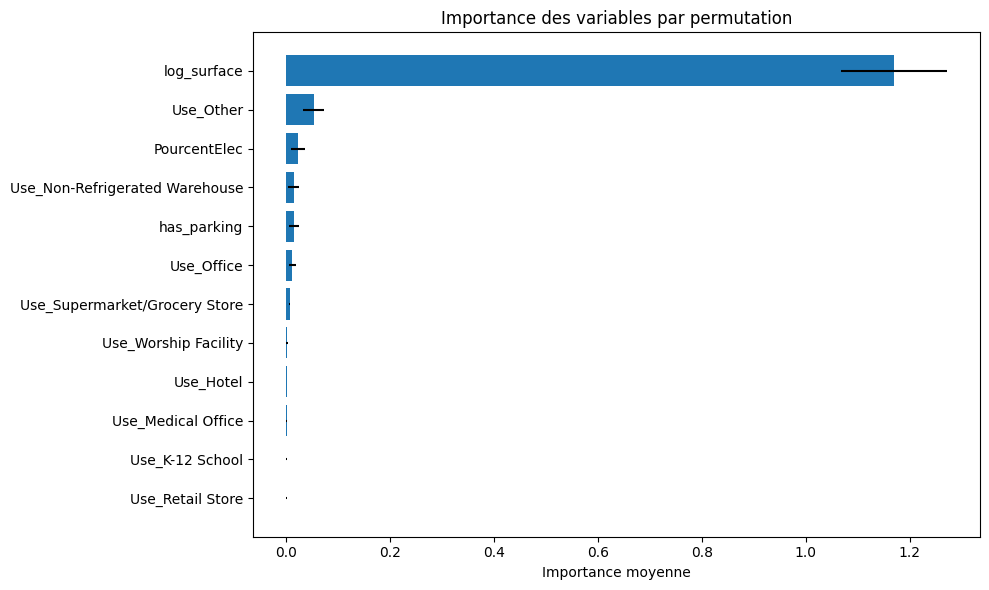

In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")

# Définir les features et la target
features = [
    "log_surface", "has_parking", "PourcentElec", "Use_Hotel", "Use_K-12 School",
    "Use_Medical Office", "Use_Non-Refrigerated Warehouse", "Use_Office",
    "Use_Other", "Use_Retail Store", "Use_Supermarket/Grocery Store", "Use_Worship Facility"
]
target = "SiteEnergyUse(kBtu)"

X = df[features]
y = df[target]

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Initialiser le modèle Random Forest avec tes meilleurs hyperparamètres
best_params = {
    'max_depth': 40,
    'max_features': 0.5,
    'min_samples_leaf': 4,
    'min_samples_split': 14,
    'n_estimators': 259
}

model = RandomForestRegressor(**best_params, random_state=42)
model.fit(X_train, y_train)

# Calcul de l’importance par permutation
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

# Résultats dans un DataFrame trié
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

# Affichage du tableau
print("\n--- Résultat : Importance des variables (Permutation Importance) ---\n")
print(importance_df.to_string(index=False))

# Optionnel : graphique de l’importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance_Mean"], xerr=importance_df["Importance_Std"])
plt.xlabel("Importance moyenne")
plt.title("Importance des variables par permutation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()




# 🌲 Analyse d’importance des variables – Méthode MDI (Random Forest)

---

## 🎯 Objectif

L’objectif est d’évaluer quelles variables influencent le plus la prédiction de la consommation énergétique (`SiteEnergyUse(kBtu)`) à l’aide d’un modèle **Random Forest**. Pour cela, on utilise une mesure interne à l’algorithme : **l’importance MDI** (*Mean Decrease in Impurity*).

---

## ⚙️ Méthode utilisée : MDI (Mean Decrease in Impurity)

La MDI est la méthode d’importance par défaut utilisée par les Random Forests dans `scikit-learn`.

### 📌 Principe :

À chaque fois qu’une variable est utilisée pour effectuer une **séparation (split)** dans un arbre :

* Elle contribue à **réduire l’impureté** (ex. : variance dans une tâche de régression).
* Cette réduction est **cumulée** sur tous les arbres de la forêt.
* À la fin, on normalise pour obtenir une **importance relative** par variable.

---

### 📐 Formule simplifiée :

Pour une variable ( X_j ), l’importance MDI est :

$text{Importance}(X_j) = \sum_{\text{noeuds utilisant } X_j} \text{Gain d’impureté à ce noeud}$

---

## 📊 Résultats observés

![Importance MDI](b751f733-8aaa-4fc6-bcf1-7345e580b5aa.png)

### ✅ Variables importantes :

| Variable         | Rôle                                                                                                             |
| ---------------- | ---------------------------------------------------------------------------------------------------------------- |
| **log_surface**  | Extrêmement importante. Plus un bâtiment est grand, plus il consomme. C’est **la variable la plus explicative**. |
| **PourcentElec** | Impact modéré. Représente le pourcentage d’électricité dans la consommation → corrélé à l’intensité énergétique. |

---

## ❓ Pourquoi seules **deux variables** ressortent ?

Il est tout à fait normal de n’avoir que quelques variables importantes avec la MDI, surtout quand :

1. 🔁 Les autres variables sont **peu utilisées** dans les arbres (elles ne font pas de splits).
2. 🧱 Elles sont **corrélées** avec une autre variable plus forte → les arbres choisissent la variable la plus efficace (ex: surface plutôt que type d’usage).
3. 📉 Elles n’apportent **aucune amélioration du modèle** → importance ≈ 0.

---

## 📌 Points forts et limites de la MDI

| ✅ Avantages                            | ⚠️ Limites & pièges                                       |
| -------------------------------------- | --------------------------------------------------------- |
| Rapide et intégrée au modèle           | Biaisée envers les variables à **beaucoup de valeurs**    |
| Facile à interpréter globalement       | Ne reflète pas l’impact **local** d’une variable          |
| Basée sur la logique interne du modèle | Ignore les variables **jamais utilisées dans les splits** |

---

## 🧠 En résumé

* `log_surface` domine largement la prédiction : c’est un **indicateur fondamental** de la consommation énergétique.
* `PourcentElec` ajoute une couche d’explication, sans être aussi structurante.
* Les autres variables (type d’usage, parking, etc.) **n’ont pas été jugées utiles par le modèle** pour diviser les données → elles reçoivent une importance MDI ≈ 0.



C:\Users\karap\AppData\Local\Temp\ipykernel_24632\448518497.py:49: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


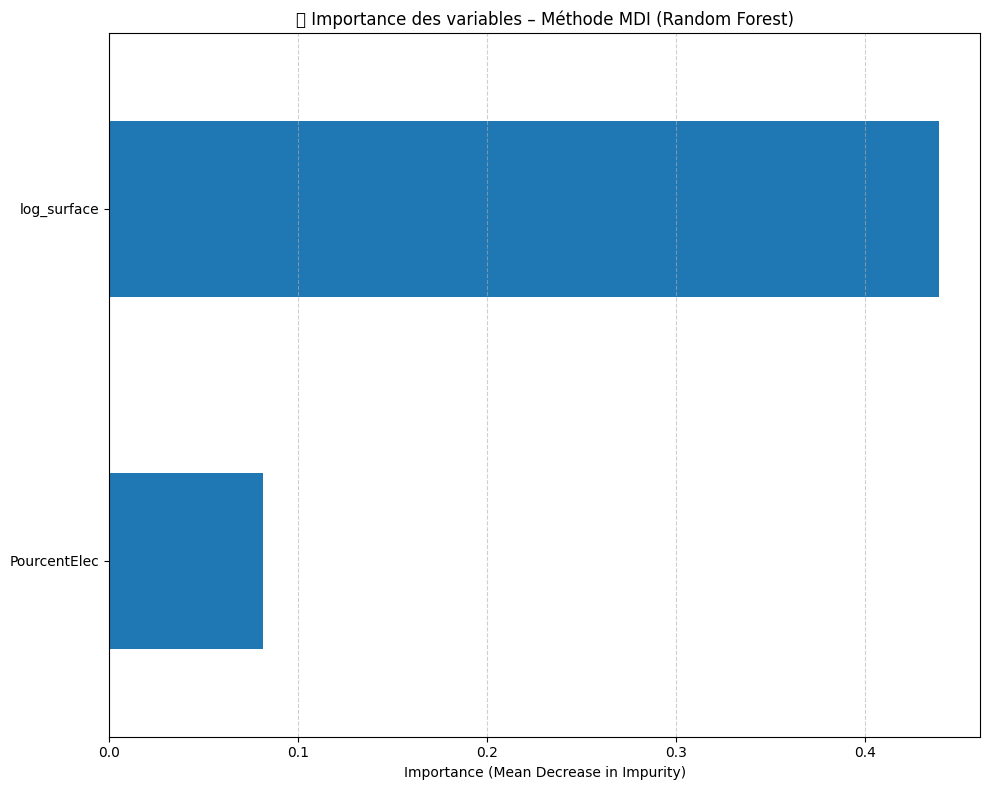

In [30]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Chargement du modèle
rf_model = joblib.load("data/random_forest_optimized_model.joblib")

# 📂 Chargement des données
df = pd.read_csv("data/feature_engineered_2016_energySpec.csv")
df.columns = df.columns.str.strip()  # Nettoyage des noms de colonnes

# ✅ Liste officielle des variables à utiliser
selected_features = [
    'log_surface',
    'has_parking',
    'PourcentElec',
    'Use_Hotel',
    'Use_K-12 School',
    'Use_Medical Office',
    'Use_Non-Refrigerated Warehouse',
    'Use_Office',
    'Use_Other',
    'Use_Retail Store',
    'Use_Supermarket/Grocery Store',
    'Use_Worship Facility'
]

# 🧽 Nettoyage : on vérifie qu’elles sont bien dans le dataset et dans le modèle
selected_features = [
    f for f in selected_features
    if f in df.columns and f in rf_model.feature_names_in_
]

# 📊 Récupération des importances MDI (Mean Decrease in Impurity)
mdi_importances = pd.Series(
    rf_model.feature_importances_,
    index=rf_model.feature_names_in_
)

# 📉 Filtrage des features sélectionnées
mdi_filtered = mdi_importances[selected_features].sort_values(ascending=True)

# 🎨 Visualisation
plt.figure(figsize=(10, 8))
mdi_filtered.plot.barh()
plt.title("🌲 Importance des variables – Méthode MDI (Random Forest)")
plt.xlabel("Importance (Mean Decrease in Impurity)")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



## 🧠 Bilan

L’objectif était de prédire la **consommation énergétique annuelle d’un bâtiment (en kBtu)** à partir de données disponibles sur sa surface, son usage, la proportion d’électricité utilisée, et d'autres caractéristiques structurelles.

### 🔧 Étapes principales du pipeline :

1. **Nettoyage et ingénierie des variables :**

   * Suppression des outliers extrêmes (surface / énergie).
   * Calcul de `log_surface` pour atténuer l’impact des très grands bâtiments.
   * Création de `PourcentElec` = proportion d’électricité dans la conso totale.
   * Regroupement des types d’usages rares.
   * Encodage one-hot des usages principaux (`UseTypeGrouped`).

2. **Sélection des variables explicatives :**

   * `log_surface`, `has_parking`, `PourcentElec`, `Use_*`
   * Puis ajout d’interactions (`log_surface * usage`, etc.) pour certains modèles avancés.

3. **Modélisation :**
   Plusieurs algorithmes ont été testés :

---

## 📊 Comparaison des modèles

| Modèle                     | R² Test | MAE (kBtu) | RMSE (kBtu) | Commentaire                                                  |
| -------------------------- | ------- | ---------- | ----------- | ------------------------------------------------------------ |
| **Régression linéaire**    | 0.626   | ~4.7M      | ~7.15M      | Bon baseline, mais sous-performant sur les grands bâtiments. |
| **Random Forest (défaut)** | 0.572   | ~3.7M      | ~7.65M      | Fort overfitting : R² train = 0.94.                          |
| **Random Forest optimisé** | 0.613   | ~3.6M      | ~7.27M      | Moins d’overfitting. Meilleur compromis.                     |
| **GradientBoosting**       | ≈ 0.59  | ~3.8M      | ~7.5M       | Performances similaires à Random Forest.                     |

---

## 🏆 Meilleur modèle retenu

✅ **Random Forest optimisé (max_depth=10, min_samples_split=10, n_estimators=300)**

* Bon compromis entre biais et variance.
* Résiste mieux au sur-apprentissage que la version par défaut.
* Simplicité d’utilisation, peu sensible à la mise à l’échelle ou aux valeurs extrêmes.


